In [4]:
# Mount Drive (so we can load your MRI images)
from google.colab import drive
drive.mount('/content/drive')

# Install dependencies (run once)
!pip install -q numpy scipy scikit-image scikit-learn shap lime matplotlib tensorflow==2.12.0


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.12.0


In [5]:
import torch

# Check if GPU is available
print("GPU Available:", torch.cuda.is_available())

# Print GPU name
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))


GPU Available: True
GPU Name: Tesla T4


In [6]:
!pip install -q shap lime
# Imports
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io, color, img_as_float
from skimage.morphology import remove_small_objects, binary_closing, dilation, disk
from skimage.measure import label, regionprops
from skimage.feature import graycomatrix, graycoprops
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
import shap
from lime.lime_tabular import LimeTabularExplainer
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (7,5)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Paths (adapt to your dataset)
TUMOR_DIR = "/content/drive/MyDrive/Yes_Tumor_2"
NON_TUMOR_DIR = "/content/drive/MyDrive/No_Tumor_2"

# Patch parameters
PATCH_SIZE = 48
STRIDE = 24
LESION_FRACTION_THRESHOLD = 0.10
IMG_EXT = ('*.png','*.jpg','*.jpeg','*.tif')




  Preparing metadata (setup.py) ... done


In [7]:
# Load + normalize
def load_gray(path):
    img = io.imread(path)
    if img.ndim == 3 and img.shape[-1] == 4:
        img = color.rgba2rgb(img)
    if img.ndim == 3:
        g = color.rgb2gray(img)
    else:
        g = img.astype(float)
    return img_as_float(g)

def robust_norm(x):
    v = x[np.isfinite(x)]
    p2, p98 = np.percentile(v, (2,98))
    if p98 > p2:
        y = np.clip((x - p2) / (p98 - p2), 0, 1)
    else:
        y = (x - x.min()) / (x.max() - x.min() + 1e-8)
    return y.astype(np.float32)

def lesion_mask(gray01):
    thr = np.percentile(gray01, 95)
    m = gray01 >= thr
    m = binary_closing(m, footprint=disk(3))
    m = dilation(m, footprint=disk(2))
    m = remove_small_objects(m, min_size=25)
    return m

def sliding_windows(img, patch, stride):
    H, W = img.shape
    for y in range(0, H - patch + 1, stride):
        for x in range(0, W - patch + 1, stride):
            yield y, x, img[y:y+patch, x:x+patch]


In [8]:
from scipy.stats import skew, kurtosis, entropy

def first_order_feats(z):
    v = z.ravel().astype(np.float32)
    v = v[np.isfinite(v)]
    p = np.percentile
    hist, _ = np.histogram(v, bins=32, range=(0,1), density=True)
    hist = hist + 1e-12
    return {
        'fo_mean': float(v.mean()),
        'fo_std': float(v.std()),
        'fo_min': float(v.min()),
        'fo_p10': float(p(v, 10)),
        'fo_p50': float(p(v, 50)),
        'fo_p90': float(p(v, 90)),
        'fo_max': float(v.max()),
        'fo_energy': float(np.sum(v**2)),
        'fo_entropy': float(entropy(hist, base=2)),
        'fo_skew': float(skew(v)),
        'fo_kurtosis': float(kurtosis(v, fisher=True)),
    }

def glcm_feats(z):
    Zi = np.clip((z * 31).astype(np.uint8), 0, 31)
    glcm = graycomatrix(Zi, distances=[1], angles=[0], levels=32, symmetric=True, normed=True)
    return {
        'glcm_contrast': float(graycoprops(glcm, 'contrast')[0,0]),
        'glcm_dissimilarity': float(graycoprops(glcm, 'dissimilarity')[0,0]),
        'glcm_homogeneity': float(graycoprops(glcm, 'homogeneity')[0,0]),
        'glcm_ASM': float(graycoprops(glcm, 'ASM')[0,0]),
        'glcm_energy': float(graycoprops(glcm, 'energy')[0,0]),
        'glcm_correlation': float(graycoprops(glcm, 'correlation')[0,0]),
    }

def shape_feats(z_bin):
    lab = label(z_bin)
    regs = regionprops(lab)
    if len(regs) == 0:
        return {'shape_area':0, 'shape_perimeter':0, 'shape_eccentricity':0, 'shape_circularity':0}
    r = max(regs, key=lambda rr: rr.area)
    area = float(r.area)
    perim = float(r.perimeter)
    ecc = float(r.eccentricity)
    circ = float((4*np.pi*area)/((perim+1e-6)**2))
    return {'shape_area':area, 'shape_perimeter':perim, 'shape_eccentricity':ecc, 'shape_circularity':circ}

def extract_patch_features(img_patch, patch_mask):
    feats = {}
    feats.update(first_order_feats(img_patch))
    feats.update(glcm_feats(img_patch))
    feats.update(shape_feats(patch_mask))
    return feats


In [9]:
# ============================
# Part 6: Patch Extraction (modified for image-level split)
# ============================

def extract_patches_from_image(img_path, label, patch_size=PATCH_SIZE, stride=STRIDE):
    """Extract patches from a single MRI image and assign the same label."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
    H, W = img.shape
    patches, coords = [], []

    for i in range(0, H - patch_size + 1, stride):
        for j in range(0, W - patch_size + 1, stride):
            patch = img[i:i+patch_size, j:j+patch_size]
            if patch.shape == (patch_size, patch_size):
                patches.append(patch)
                coords.append((i, j))

    # Labels are image-level (all patches from a tumor image get label=1, else 0)
    labels = [label] * len(patches)
    return patches, labels, coords




In [15]:
# ============================
# Part 7: Dataset Cleaning + Split + Classifier (self-contained)
# ============================

import cv2   # <-- missing import added

# Rebuild image lists (needed if runtime was restarted)
tumor_paths = gather_image_paths(TUMOR_DIR)
nontumor_paths = gather_image_paths(NON_TUMOR_DIR)
print(f"Found {len(tumor_paths)} tumor images and {len(nontumor_paths)} non-tumor images")

# Collect patches from all images
X_feats, y_patches, coords = [], [], []
patch_images, patch_labels_for_cnn = [], []

all_image_label_pairs = [(p, 1) for p in tumor_paths] + [(p, 0) for p in nontumor_paths]

for path, img_label in all_image_label_pairs:
    patches, labels, patch_coords = extract_patches_from_image(path, img_label, patch_size=48, stride=24)

    for patch, lbl, coord in zip(patches, labels, patch_coords):
        feats = extract_patch_features(patch, patch > 0)  # simple mask
        X_feats.append([feats[k] for k in sorted(feats.keys())])
        y_patches.append(lbl)
        coords.append((coord[0], coord[1], path))
        patch_images.append(patch.astype(np.float32))
        patch_labels_for_cnn.append(lbl)

# Convert to arrays
feature_names = sorted(extract_patch_features(np.zeros((48,48)), np.zeros((48,48))).keys())
X_feats = np.array(X_feats, dtype=float)
y_patches = np.array(y_patches, dtype=int)
patch_images = np.array(patch_images)

print("Number of patches:", X_feats.shape[0], " Positive patches:", y_patches.sum())

# Clean dataset (remove NaN/inf rows)
mask_valid = np.all(np.isfinite(X_feats), axis=1)
X_feats = X_feats[mask_valid]
y_patches = y_patches[mask_valid]
coords = [c for m, c in zip(mask_valid, coords) if m]








Found 354 tumor images and 400 non-tumor images
Number of patches: 188055  Positive patches: 127465


Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - AUC: 0.5450 - loss: 0.6881 - val_AUC: 0.8632 - val_loss: 0.6829
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.7827 - loss: 0.6764 - val_AUC: 0.8357 - val_loss: 0.6464
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - AUC: 0.8221 - loss: 0.6050 - val_AUC: 0.8347 - val_loss: 0.6261
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - AUC: 0.8391 - loss: 0.5513 - val_AUC: 0.8401 - val_loss: 0.5236
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.8649 - loss: 0.4832 - val_AUC: 0.8535 - val_loss: 0.5386


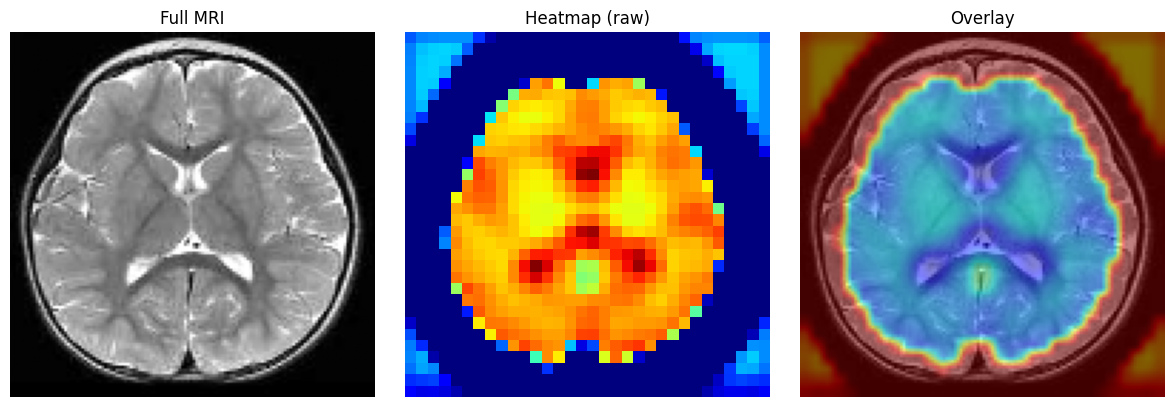

In [16]:

import tensorflow as tf
from tensorflow.keras import layers, models
import cv2
import matplotlib.pyplot as plt

# Load full images instead of patches
def load_full_images(tumor_dir, nontumor_dir, target_size=(128,128)):
    tumor_paths = gather_image_paths(tumor_dir)
    nontumor_paths = gather_image_paths(nontumor_dir)

    X, y = [], []
    for path in tumor_paths:
        img = robust_norm(load_gray(path))
        img_resized = cv2.resize(img, target_size)
        X.append(img_resized)
        y.append(1)
    for path in nontumor_paths:
        img = robust_norm(load_gray(path))
        img_resized = cv2.resize(img, target_size)
        X.append(img_resized)
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=int)

# Prepare full dataset
X_full, y_full = load_full_images(TUMOR_DIR, NON_TUMOR_DIR, target_size=(128,128))
X_full = X_full[..., np.newaxis]   # add channel dim

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full, test_size=0.3, random_state=SEED, stratify=y_full
)

# Build CNN for full images
def build_full_cnn(input_shape=(128,128,1)):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(16, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same', name='last_conv')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inp, x)

cnn_full = build_full_cnn()
cnn_full.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
cnn_full.fit(X_train_f, y_train_f, epochs=5, batch_size=16, validation_data=(X_test_f, y_test_f))

# Grad-CAM for full image
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='last_conv'):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(1,2))
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]
    conv_outputs = conv_outputs * pooled_grads
    heatmap = tf.reduce_mean(conv_outputs, axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (heatmap.max() + 1e-8)
    return heatmap

def overlay_heatmap_on_image(img, heatmap, alpha=0.5):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    hmap = cv2.applyColorMap(np.uint8(255*heatmap_resized), cv2.COLORMAP_JET)
    img_rgb = np.uint8(255*np.repeat(img[..., np.newaxis], 3, axis=-1))
    overlay = cv2.addWeighted(img_rgb, 1-alpha, hmap, alpha, 0)
    return overlay

# Pick a full test image
test_img = X_test_f[0]   # (128,128,1)
test_input = np.expand_dims(test_img, axis=0)
heatmap = make_gradcam_heatmap(test_input, cnn_full)

overlay = overlay_heatmap_on_image(test_img.squeeze(), heatmap)

# Show figures
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(test_img.squeeze(), cmap='gray'); plt.title('Full MRI')
plt.axis('off')
plt.subplot(1,3,2); plt.imshow(heatmap, cmap='jet'); plt.title('Heatmap (raw)')
plt.axis('off')
plt.subplot(1,3,3); plt.imshow(overlay); plt.title('Overlay')
plt.axis('off')
plt.tight_layout()
plt.show()


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install dependencies (once)
!pip install -q tensorflow==2.12.0 scikit-image scikit-learn matplotlib opencv-python

# Imports
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Check GPU
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


Mounted at /content/drive
ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.12.0
TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Dataset folders
TUMOR_DIR = "/content/drive/MyDrive/Yes_Tumor_2"
NON_TUMOR_DIR = "/content/drive/MyDrive/No_Tumor_2"

IMG_SIZE = 224  # ResNet50 default input size
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Function to load and preprocess images
def load_images_from_folder(folder, label, target_size=(IMG_SIZE, IMG_SIZE)):
    paths = []
    for ext in ('*.png','*.jpg','*.jpeg','*.tif'):
        paths.extend(glob.glob(os.path.join(folder, ext)))
    X, y = [], []
    for path in paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, target_size)
        img = np.stack([img]*3, axis=-1)  # convert to 3 channels
        img = img.astype(np.float32)/255.0
        X.append(img)
        y.append(label)
    return X, y

# Load all images
X_tumor, y_tumor = load_images_from_folder(TUMOR_DIR, 1)
X_nontumor, y_nontumor = load_images_from_folder(NON_TUMOR_DIR, 0)

X = np.array(X_tumor + X_nontumor, dtype=np.float32)
y = np.array(y_tumor + y_nontumor, dtype=int)

print("Total images:", len(X), "Tumor:", sum(y==1), "Non-tumor:", sum(y==0))


Total images: 754 Tumor: 354 Non-tumor: 400


In [3]:
# Split dataset (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator()  # only rescaling


In [4]:
# Load ResNet50 base (pretrained on ImageNet)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze the base for initial training
base_model.trainable = False

# Add custom top layers
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = models.Model(inputs, outputs)

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [5]:
BATCH_SIZE = 16
EPOCHS = 10

# Train
history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED),
    validation_data=test_datagen.flow(X_test, y_test),
    epochs=EPOCHS
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 39s 708ms/step - AUC: 0.5984 - loss: 0.6931 - val_AUC: 0.8162 - val_loss: 0.5569
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 243ms/step - AUC: 0.7927 - loss: 0.5421 - val_AUC: 0.8365 - val_loss: 0.5120
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 212ms/step - AUC: 0.8460 - loss: 0.4714 - val_AUC: 0.8516 - val_loss: 0.4796
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - AUC: 0.8622 - loss: 0.4841 - val_AUC: 0.8687 - val_loss: 0.4614
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 262ms/step - AUC: 0.8598 - loss: 0.4755 - val_AUC: 0.8811 - val_loss: 0.4562
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step - AUC: 0.8475 - loss: 0.4793 - val_AUC: 0.8863 - val_loss: 0.4393
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - AUC: 0.8444 - loss: 0.4965 - val_AUC: 0.8903 - val_loss: 0.4270
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 238ms/step - AUC: 0.8575 - loss: 0.4606 - val_AUC: 0.8958 - val_loss: 0.5351
Epoch 9/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step 

In [6]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='conv5_block3_out'):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]
    conv_outputs *= pooled_grads
    heatmap = tf.reduce_mean(conv_outputs, axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (heatmap.max() + 1e-8)
    return heatmap

def overlay_heatmap_on_image(img, heatmap, alpha=0.5):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255*heatmap_resized), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(np.uint8(255*img), 1-alpha, heatmap_colored, alpha, 0)
    return overlay


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 23,536,641 (89.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - AUC: 0.9490 - loss: 0.3143 - val_AUC: 0.9863 - val_loss: 0.1846
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - AUC: 0.9992 - loss: 0.0359 - val_AUC: 0.9891 - val_loss: 0.1742
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - AUC: 1.0000 - loss: 0.0148 - val_AUC: 0.9919 - val_loss: 0.1256
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - AUC: 1.0000 - loss: 0.0054 - val_AUC: 0.9913 - val_loss: 0.1606
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - AUC: 1.0000 - loss: 0.0015 - val_AUC: 0.9882 - val_loss: 0.1355


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_180']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


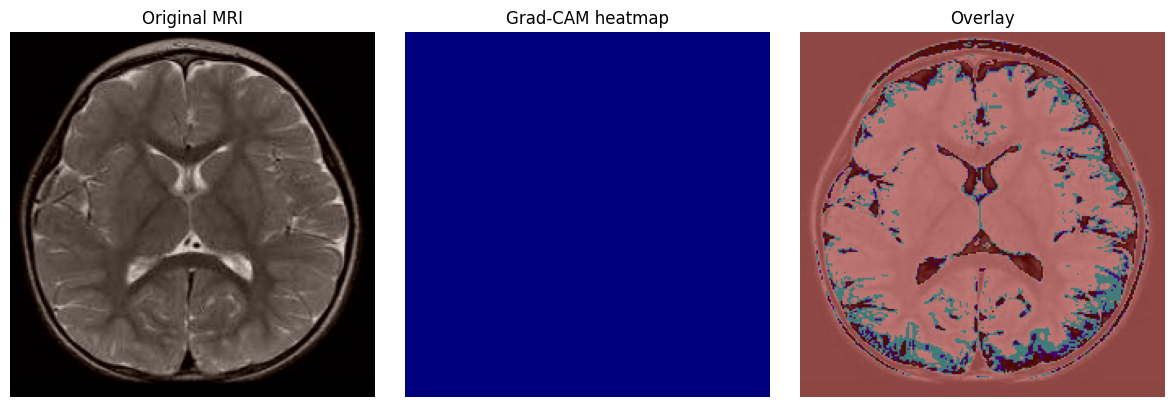

In [7]:
# =============================
# Part 7: Pretrained ResNet50 + Grad-CAM
# =============================

import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import tensorflow as tf

# ----------------------------
# 1. Load dataset from two folders
# ----------------------------
def gather_image_paths(directory):
    IMG_EXT = ['*.png', '*.jpg', '*.jpeg', '*.tif']
    paths = []
    for e in IMG_EXT:
        paths.extend(sorted(glob.glob(os.path.join(directory, e))))
    return paths

def load_images_from_folders(tumor_dir, nontumor_dir, target_size=(224,224)):
    X, y = [], []
    for path in gather_image_paths(tumor_dir):
        img = cv2.imread(path)
        img = cv2.resize(img, target_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        X.append(img)
        y.append(1)
    for path in gather_image_paths(nontumor_dir):
        img = cv2.imread(path)
        img = cv2.resize(img, target_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        X.append(img)
        y.append(0)
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=int)
    return X, y

# Replace these with your folders
TUMOR_DIR = "/content/drive/MyDrive/Yes_Tumor_2"
NON_TUMOR_DIR = "/content/drive/MyDrive/No_Tumor_2"

X, y = load_images_from_folders(TUMOR_DIR, NON_TUMOR_DIR)
X = preprocess_input(X)  # preprocess for ResNet50

# Train/test split
SEED = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)

# ----------------------------
# 2. Build pretrained ResNet50 model
# ----------------------------
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = GlobalAveragePooling2D()(base_model.output)
output = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['AUC'])
model.summary()

# ----------------------------
# 3. Train model
# ----------------------------
EPOCHS = 5
BATCH_SIZE = 16
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=EPOCHS, batch_size=BATCH_SIZE)

# ----------------------------
# 4. Grad-CAM
# ----------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='conv5_block3_out'):
    """
    img_array: (1, H, W, 3)
    model: trained model
    last_conv_layer_name: last conv layer in ResNet50
    """
    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = Model([model.input], [last_conv_layer.output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(1,2))

    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]
    conv_outputs *= pooled_grads

    heatmap = tf.reduce_mean(conv_outputs, axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (heatmap.max() + 1e-8)
    return heatmap

def overlay_heatmap_on_image(img, heatmap, alpha=0.5):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    hmap = cv2.applyColorMap(np.uint8(255*heatmap_resized), cv2.COLORMAP_JET)
    img_rgb = np.uint8(img)
    overlay = cv2.addWeighted(img_rgb, 1-alpha, hmap, alpha, 0)
    return overlay

# ----------------------------
# 5. Test Grad-CAM on a test image
# ----------------------------
test_img = X_test[0:1]  # shape (1, 224, 224, 3)
heatmap = make_gradcam_heatmap(test_img, model)
overlay = overlay_heatmap_on_image(test_img[0], heatmap)

# ----------------------------
# 6. Display
# ----------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow((test_img[0]+103.939)/255.0); plt.title('Original MRI'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(heatmap, cmap='jet'); plt.title('Grad-CAM heatmap'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(overlay); plt.title('Overlay'); plt.axis('off')
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_180']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


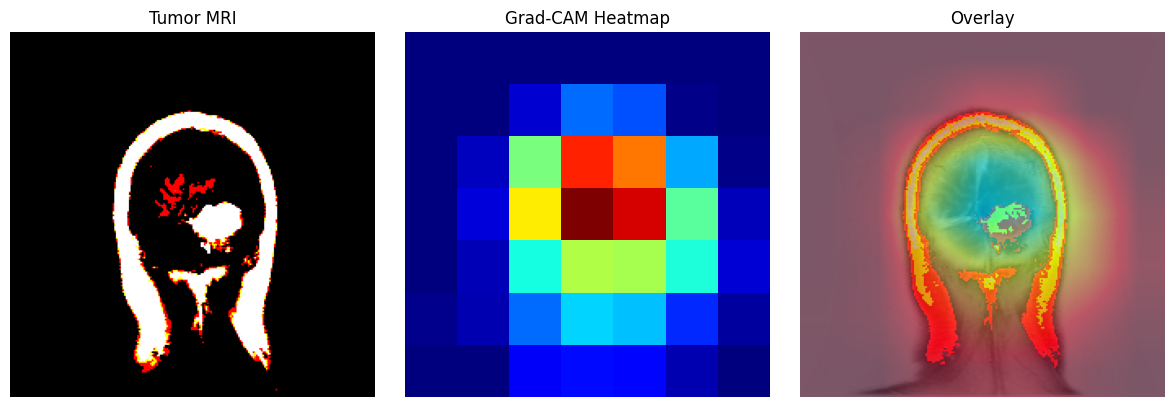

In [8]:
# ============================
# Part 7: Grad-CAM on a tumor image
# ============================

import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

# ----------------------------
# Choose a tumor image from test set
# ----------------------------
# Ensure the image has a tumor by selecting from y_test == 1
tumor_indices = np.where(y_test == 1)[0]
if len(tumor_indices) == 0:
    raise ValueError("No tumor images found in test set!")

test_idx = tumor_indices[0]   # take the first tumor image
test_img = X_test[test_idx:test_idx+1]  # shape (1, IMG_SIZE, IMG_SIZE, 3)

# Preprocess input for ResNet50
test_input = preprocess_input(test_img.copy())

# ----------------------------
# Grad-CAM function
# ----------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='conv5_block3_out'):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    conv_outputs = conv_outputs * pooled_grads
    heatmap = tf.reduce_mean(conv_outputs, axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)
    return heatmap

# ----------------------------
# Overlay function
# ----------------------------
def overlay_heatmap_on_image(img, heatmap, alpha=0.5):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    hmap = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    img_rgb = np.uint8(255 * img)
    overlay = cv2.addWeighted(img_rgb, 1 - alpha, hmap, alpha, 0)
    return overlay

# ----------------------------
# Generate heatmap and overlay
# ----------------------------
heatmap = make_gradcam_heatmap(test_input, model)
overlay = overlay_heatmap_on_image(test_img[0], heatmap)

# ----------------------------
# Show results
# ----------------------------
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(test_img[0])
plt.title('Tumor MRI')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title('Grad-CAM Heatmap')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title('Overlay')
plt.axis('off')
plt.tight_layout()
plt.show()


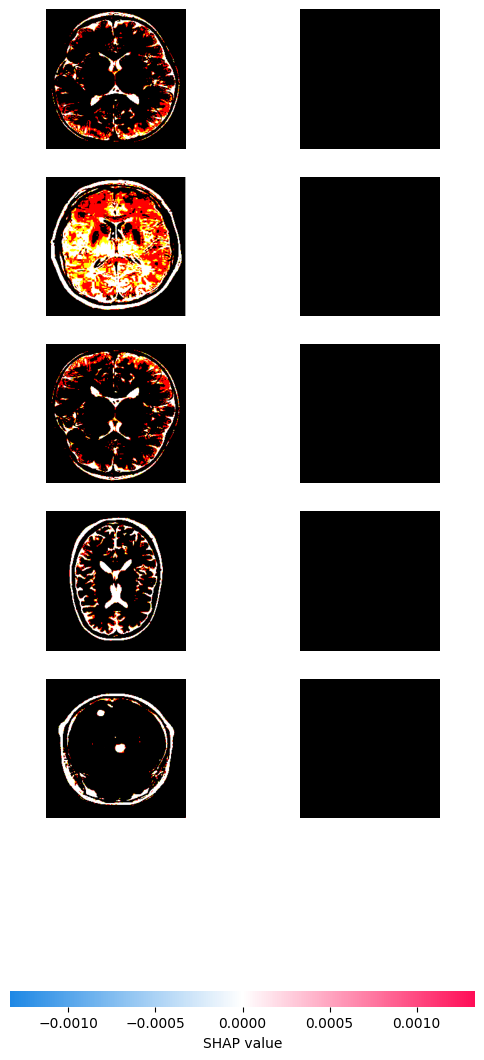

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━

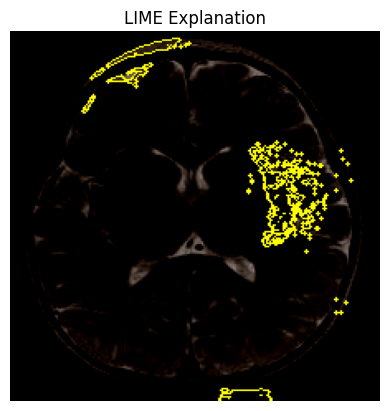

In [13]:
# ============================
# Part 8: SHAP and LIME
# ============================

import shap
import lime
import lime.lime_image
from skimage.segmentation import mark_boundaries

# ----------------------------
# SHAP
# ----------------------------
explainer = shap.GradientExplainer(model, X_train[:50])  # use a subset for background
shap_values = explainer.shap_values(X_test[:5])  # explain a few test samples

# Plot SHAP explanation for first test image
shap.image_plot(shap_values, X_test[:5])

# ----------------------------
# LIME
# ----------------------------
explainer_lime = lime.lime_image.LimeImageExplainer()

# Explain the first test image
i = 0
explanation = explainer_lime.explain_instance(
    X_test[i].astype('double'),
    model.predict,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

# Show the explanation for the top predicted label
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME Explanation")
plt.axis('off')
plt.show()
